In [ ]:
!pip install -U keras-cv tensorflow
!pip install -U efficientnet
!pip install keras-cv
!pip install   scikit-optimize optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.3 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompa

ResNet50 + ViT-B/16

GPU CONFIGURATION CHECK
✅ GPU Available: 2 device(s)
   - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
   - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
✅ Memory growth enabled and memory limit set

TensorFlow version: 2.20.0
Keras version: 3.10.0
✅ Mixed precision enabled: mixed_float16

🎲 Global seed set to: 42

TRAINING CONFIGURATION
Image Size: (224, 224)
Batch Size: 24
Epochs: 20
Learning Rate: 0.0001

LOADING DATA
Found 16800 images belonging to 3 classes.
Found 3600 images belonging to 3 classes.

📁 Dataset Info:
   Classes: ['one_molecule', 'reactions', 'several_molecules']
   Number of classes: 3
   Training samples: 16800
   Validation samples: 3600

BUILDING MODEL: EfficientNetB3 + ViT-B/16 (Memory Optimized)


I0000 00:00:1767641979.876172      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14000 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767641979.877026      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14000 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📋 Model Summary:


Model: "EfficientNetB3_ViT_Ensemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 1536)      │ 10,783,535 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ViT_B16_Lite        │ (None, 512)       │ 19,309,056 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 2048)      │          0 │ efficientnetb3[0… │
│ (Concatenate)       │                   │            │ ViT_B16_Lite[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense1       │ (None, 256)       │    524,544 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn1          │ (None, 256)       │      1,024 │ fusion_dense1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout1     │ (None, 256)       │          0 │ fusion_bn1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        771 │ fusion_dropout1[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...


📊 Model Parameters:
   Total: 30,618,930
   Trainable: 19,834,883
   Non-trainable: 10,784,047

🎨 Generating model architecture diagram...
✅ Architecture saved as 'efficientnetb3_vit_ensemble_architecture.png'

🚀 STARTING TRAINING


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1767642084.402154     107 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


700/700 ━━━━━━━━━━━━━━━━━━━━ 420s 435ms/step - accuracy: 0.4503 - loss: 1.0715 - val_accuracy: 0.3783 - val_loss: 1.8795 - learning_rate: 1.0000e-04
Epoch 2/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 196s 280ms/step - accuracy: 0.4882 - loss: 1.0065 - val_accuracy: 0.3333 - val_loss: 2.8194 - learning_rate: 1.0000e-04
Epoch 3/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 196s 279ms/step - accuracy: 0.5865 - loss: 0.8817 - val_accuracy: 0.3550 - val_loss: 1.3998 - learning_rate: 1.0000e-04
Epoch 4/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 198s 283ms/step - accuracy: 0.6197 - loss: 0.8367 - val_accuracy: 0.5453 - val_loss: 1.0540 - learning_rate: 1.0000e-04
Epoch 5/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 194s 277ms/step - accuracy: 0.6533 - loss: 0.7807 - val_accuracy: 0.6172 - val_loss: 0.8114 - learning_rate: 1.0000e-04
Epoch 6/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 198s 283ms/step - accuracy: 0.6619 - loss: 0.7777 - val_accuracy: 0.6064 - val_loss: 0.8445 - learning_rate: 1.0000e-04
Epoch 7/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 194s 278ms/

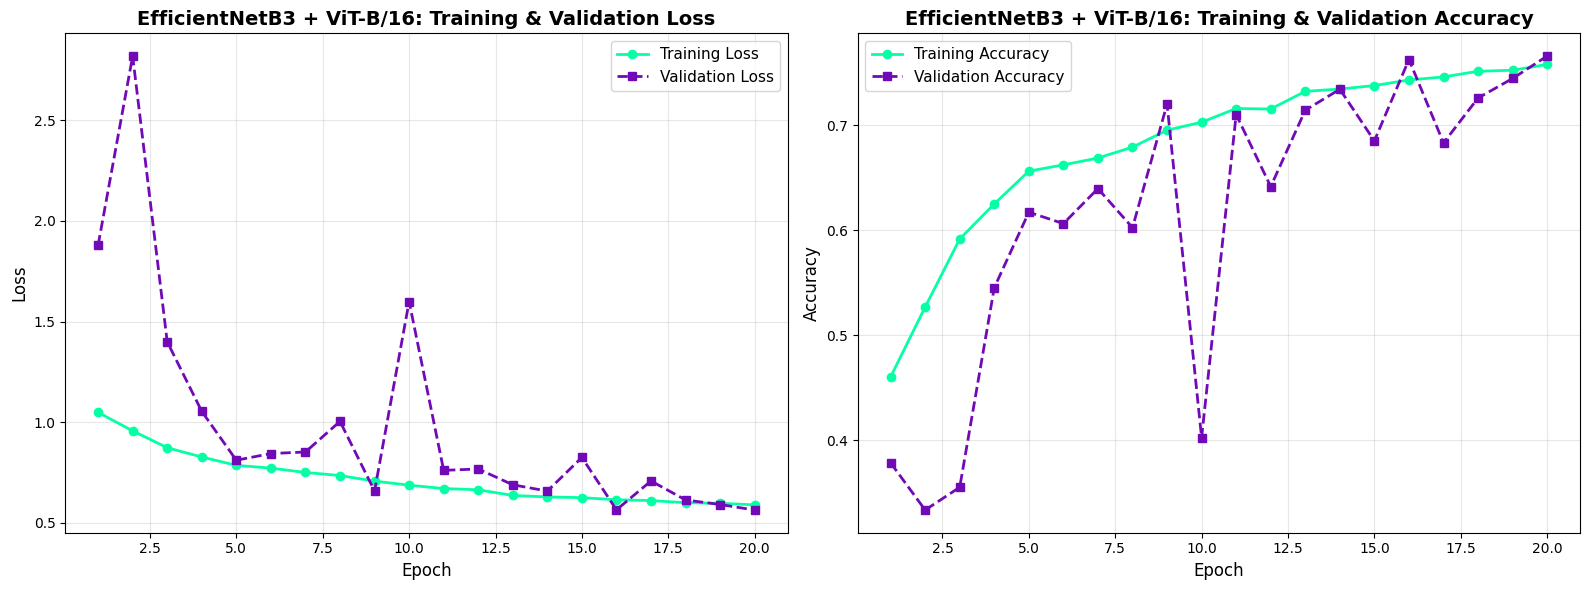


📊 EVALUATION ON VALIDATION SET
150/150 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step

📈 PERFORMANCE METRICS
Accuracy:  76.61%
Precision: 76.99%
Recall:    76.61%
F1-Score:  76.59%

⏱️  Inference Time: 37.81s
⚡ Avg Time per Sample: 10.50ms

📋 DETAILED CLASSIFICATION REPORT
                   precision    recall  f1-score   support

     one_molecule     0.7794    0.8625    0.8188      1200
        reactions     0.6861    0.7050    0.6954      1200
several_molecules     0.8441    0.7308    0.7834      1200

         accuracy                         0.7661      3600
        macro avg     0.7699    0.7661    0.7659      3600
     weighted avg     0.7699    0.7661    0.7659      3600



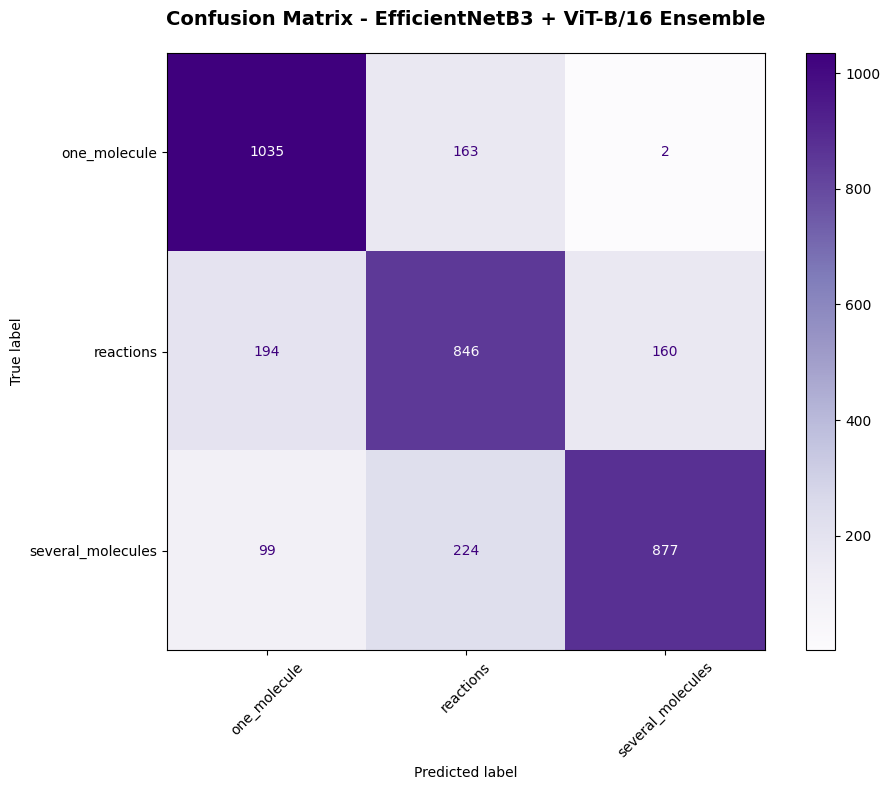


🎉 ENSEMBLE MODEL 3 EXECUTION COMPLETE!
Model: EfficientNetB3 + ViT-B/16
Training Time: 69m 27s
Final Validation Accuracy: 76.61%
F1-Score: 76.59%


In [ ]:
"""
Ensemble Model 3: EfficientNetB3 + ViT-B/16
Chemical Image Classification
GPU-Optimized for Kaggle T4 (OOM Prevention)
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import random
import time
import gc

# GPU Configuration and Verification
print("="*70)
print("GPU CONFIGURATION CHECK")
print("="*70)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"   - {gpu}")
        # Enable memory growth to prevent OOM
        tf.config.experimental.set_memory_growth(gpu, True)
        # Set memory limit to 14GB (safe for T4 GPU with 16GB)
        tf.config.set_logical_device_configuration(
            gpu,
            [tf.config.LogicalDeviceConfiguration(memory_limit=14000)]
        )
    print("✅ Memory growth enabled and memory limit set")
else:
    print("⚠️  No GPU detected! Running on CPU")

print(f"\nTensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Mixed precision for better performance and lower memory usage
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)
print(f"✅ Mixed precision enabled: {policy.name}")

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"\n🎲 Global seed set to: {SEED}")

# Configuration - Reduced batch size to prevent OOM
TRAIN_DIR = "/kaggle/input/chemical-image-preprocessed/Preprocessed/train"
VAL_DIR = "/kaggle/input/chemical-image-preprocessed/Preprocessed/validation"
TEST_DIR = "/kaggle/input/chemical-image-preprocessed/Preprocessed/test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 24  # Further reduced from 32 for EfficientNetB3
EPOCHS = 20
LEARNING_RATE = 0.0001

print("\n" + "="*70)
print("TRAINING CONFIGURATION")
print("="*70)
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")

# Data generators
print("\n" + "="*70)
print("LOADING DATA")
print("="*70)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())
print(f"\n📁 Dataset Info:")
print(f"   Classes: {class_names}")
print(f"   Number of classes: {num_classes}")
print(f"   Training samples: {train_generator.n}")
print(f"   Validation samples: {val_generator.n}")

# Build Vision Transformer B/16 (Lightweight version)
def create_vit_b16_lite(input_shape, num_classes):
    """Lightweight Vision Transformer Base/16 architecture for T4 GPU"""
    inputs = layers.Input(shape=input_shape)

    # Patch embedding (16x16 patches)
    patch_size = 16
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    projection_dim = 512  # Reduced from 768

    # Create patches
    patches = layers.Conv2D(projection_dim, kernel_size=patch_size, strides=patch_size, padding='valid')(inputs)
    patches = layers.Reshape((num_patches, projection_dim))(patches)

    # Position embeddings
    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    x = patches + pos_embedding

    # Transformer encoder blocks (6 blocks instead of 10)
    num_transformer_blocks = 6
    num_heads = 8  # Reduced from 12
    mlp_dim = 2048  # Reduced from 3072

    for i in range(num_transformer_blocks):
        # Layer normalization
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)

        # Multi-head attention
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim // num_heads,
            dropout=0.1
        )(x1, x1)

        # Skip connection
        x2 = layers.Add()([attention_output, x])

        # Layer normalization
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        # MLP
        x3 = layers.Dense(mlp_dim, activation=tf.nn.gelu)(x3)
        x3 = layers.Dropout(0.1)(x3)
        x3 = layers.Dense(projection_dim)(x3)
        x3 = layers.Dropout(0.1)(x3)

        # Skip connection
        x = layers.Add()([x3, x2])

    # Final layer normalization
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    return Model(inputs=inputs, outputs=x, name='ViT_B16_Lite')

# Build Ensemble Model
def create_ensemble_model(input_shape, num_classes):
    """EfficientNetB3 + ViT-B/16 Ensemble (Memory Optimized)"""
    inputs = layers.Input(shape=input_shape)

    # Branch 1: EfficientNetB3 (Efficient CNN with Compound Scaling)
    efficientnet = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    efficientnet.trainable = False  # Freeze initially
    efficient_output = efficientnet(inputs)

    # Branch 2: ViT-B/16 (Transformer)
    vit_model = create_vit_b16_lite(input_shape, num_classes)
    vit_output = vit_model(inputs)

    # Fusion Layer (Simplified)
    concat = layers.Concatenate(name='feature_fusion')([efficient_output, vit_output])

    # Classification Head (Smaller)
    x = layers.Dense(256, activation='relu', name='fusion_dense1')(concat)
    x = layers.BatchNormalization(name='fusion_bn1')(x)
    x = layers.Dropout(0.3, name='fusion_dropout1')(x)

    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32', name='output')(x)

    return Model(inputs=inputs, outputs=outputs, name='EfficientNetB3_ViT_Ensemble')

# Create model
print("\n" + "="*70)
print("BUILDING MODEL: EfficientNetB3 + ViT-B/16 (Memory Optimized)")
print("="*70)

model = create_ensemble_model(IMG_SIZE + (3,), num_classes)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
print("\n📋 Model Summary:")
model.summary()

# Count parameters
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params
print(f"\n📊 Model Parameters:")
print(f"   Total: {total_params:,}")
print(f"   Trainable: {trainable_params:,}")
print(f"   Non-trainable: {non_trainable_params:,}")

# Plot model architecture
print("\n🎨 Generating model architecture diagram...")
try:
    tf.keras.utils.plot_model(
        model,
        to_file='efficientnetb3_vit_ensemble_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        show_dtype=True,
        dpi=96,
        expand_nested=False
    )
    print("✅ Architecture saved as 'efficientnetb3_vit_ensemble_architecture.png'")
except Exception as e:
    print(f"⚠️  Could not save architecture diagram: {e}")

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# Clear memory before training
gc.collect()
tf.keras.backend.clear_session()

# Training
print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)

start_time = time.time()

try:
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    training_time = time.time() - start_time

    print("\n" + "="*70)
    print("✅ TRAINING COMPLETE!")
    print("="*70)
    print(f"⏱️  Total Training Time: {training_time//60:.0f}m {training_time%60:.0f}s")

except Exception as e:
    print(f"\n❌ Training failed with error: {e}")
    raise

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs_range, history.history['loss'], 'o-', color='#06FFA5', label='Training Loss', linewidth=2, markersize=6)
ax1.plot(epochs_range, history.history['val_loss'], 's--', color='#7209B7', label='Validation Loss', linewidth=2, markersize=6)
ax1.set_title("EfficientNetB3 + ViT-B/16: Training & Validation Loss", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history.history['accuracy'], 'o-', color='#06FFA5', label='Training Accuracy', linewidth=2, markersize=6)
ax2.plot(epochs_range, history.history['val_accuracy'], 's--', color='#7209B7', label='Validation Accuracy', linewidth=2, markersize=6)
ax2.set_title("EfficientNetB3 + ViT-B/16: Training & Validation Accuracy", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficientnetb3_vit_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation
print("\n" + "="*70)
print("📊 EVALUATION ON VALIDATION SET")
print("="*70)

val_generator.reset()
eval_start = time.time()
y_pred_probs = model.predict(val_generator, verbose=1)
eval_time = time.time() - eval_start

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# Metrics
accuracy = 100 * np.sum(y_pred == y_true) / len(y_true)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n{'='*70}")
print("📈 PERFORMANCE METRICS")
print(f"{'='*70}")
print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")
print(f"\n⏱️  Inference Time: {eval_time:.2f}s")
print(f"⚡ Avg Time per Sample: {eval_time/len(y_true)*1000:.2f}ms")

print("\n" + "="*70)
print("📋 DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Purples', ax=ax, xticks_rotation=45, values_format='d')
plt.title("Confusion Matrix - EfficientNetB3 + ViT-B/16 Ensemble", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('efficientnetb3_vit_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Final Summary
print("\n" + "="*70)
print("🎉 ENSEMBLE MODEL 3 EXECUTION COMPLETE!")
print("="*70)
print(f"Model: EfficientNetB3 + ViT-B/16")
print(f"Training Time: {training_time//60:.0f}m {training_time%60:.0f}s")
print(f"Final Validation Accuracy: {accuracy:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")
print("="*70)